**1. Mounting Google Drive in Colab**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**2. Install library**

In [3]:
!pip install missingno
!pip install xgboost
!pip install hyperopt

In [4]:
!pip install skrebate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.4/55.4 kB 2.2 MB/s eta 0:00:00


In [5]:
!pip install scikit-optimize #bayesian

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 5.7 MB/s eta 0:00:00


In [6]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 20.1 MB/s eta 0:00:00


**2) Ablation Analysis**

In [7]:
# FEATURE ABLATION EXPERIMENT
# Feature-group and model selection using Training/Validation

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from skopt import BayesSearchCV
from skopt.space import Real, Integer

# STEP 1: FEATURE GROUP DATASETS
feature_groups = {
    'Morphological':
        '/content/drive/MyDrive/In-Ovo_Sexing_Duck_Eggs/Features/Morphological.csv',
    'Embryologic Vascular':
        '/content/drive/MyDrive/In-Ovo_Sexing_Duck_Eggs/Features/Embryologic_Vascular.csv',
    'Textural (GLCM)':
        '/content/drive/MyDrive/In-Ovo_Sexing_Duck_Eggs/Features/Textural_GLCM.csv',
    'Morphological + Embryologic Vascular':
        '/content/drive/MyDrive/In-Ovo_Sexing_Duck_Eggs/Features/Morphological_Embryologic_Vascular.csv',
    'Morphological + Textural (GLCM)':
        '/content/drive/MyDrive/In-Ovo_Sexing_Duck_Eggs/Features/Morphological_Textural_GLCM.csv',
    'Embryologic Vascular + Textural (GLCM)':
        '/content/drive/MyDrive/In-Ovo_Sexing_Duck_Eggs/Features/Embryologic_Vascular_Textural_GLCM.csv',
    'Morphological + Embryologic Vascular + Textural (GLCM)':
        '/content/drive/MyDrive/In-Ovo_Sexing_Duck_Eggs/Features/Morphological_Embryologic_Vascular_Textural_GLCM.csv'
}

# STEP 2: DEFINE MODELS AND SEARCH SPACES
models = {
    'Logistic Regression': {
        'model': LogisticRegression(
            max_iter=1000,
            random_state=42
        ),
        'params': {
            'C': Real(0.01, 100, prior='log-uniform')
        },
        'scale': True
    },

    'Random Forest': {
        'model': RandomForestClassifier(
            random_state=42
        ),
        'params': {
            'n_estimators': Integer(100, 300),
            'max_depth': Integer(3, 10),
            'min_samples_split': Integer(2, 10),
            'min_samples_leaf': Integer(1, 5)
        },
        'scale': False
    },

    'SVM-RBF': {
        'model': SVC(
            kernel='rbf',
            probability=True,
            random_state=42
        ),
        'params': {
            'C': Real(0.1, 100, prior='log-uniform'),
            'gamma': Real(1e-4, 1e-1, prior='log-uniform')
        },
        'scale': True
    },

    'XGBoost': {
        'model': XGBClassifier(
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        ),
        'params': {
            'n_estimators': Integer(100, 300),
            'max_depth': Integer(3, 7),
            'learning_rate': Real(0.01, 0.2, prior='log-uniform'),
            'subsample': Real(0.8, 1.0),
            'colsample_bytree': Real(0.8, 1.0)
        },
        'scale': False
    }
}

# STEP 3: EXPERIMENT
results = []
for feature_name, file_path in feature_groups.items():
    print("\n" + "=" * 70)
    print(f"FEATURE GROUP: {feature_name}")
    print("=" * 70)

    df = pd.read_csv(file_path)
    # F = Female = 0
    # M = Male   = 1
    df['Class'] = df['Class'].map({'F': 0, 'M': 1})
    X = df.drop(
        columns=['Class', 'Image_Number']
    ).values
    y = df['Class'].values
    print(f"Total experimental eggs: {len(X)}")

    # Split 503 eggs:
    # 403 Training/Validation
    # 100 Untouched Test
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X,
        y,
        test_size=100,
        stratify=y,
        random_state=42
    )
    print(f"Training/Validation: {len(X_trainval)}")
    print(f"Untouched Test:      {len(X_test)}")

    # Training / Validation split
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval,
        y_trainval,
        test_size=50,
        stratify=y_trainval,
        random_state=42
    )
    print(f"Training:            {len(X_train)}")
    print(f"Validation:          {len(X_val)}")

    # IMPORTANT:
    # The test set is NOT used below.
    for model_name, m in models.items():
        print(f"\n--- {model_name} ---")

        # Scaling
        if m['scale']:
            scaler = RobustScaler().fit(X_train)
            X_train_s = scaler.transform(X_train)
            X_val_s = scaler.transform(X_val)
            X_tr = X_train_s
            X_v = X_val_s
        else:
            X_tr = X_train
            X_v = X_val
        # Bayesian Hyperparameter Optimization
        # using TRAINING data only

        bayes = BayesSearchCV(
            estimator=m['model'],
            search_spaces=m['params'],
            cv=StratifiedKFold(
                n_splits=10,
                shuffle=True,
                random_state=42
            ),
            n_iter=32,
            scoring='accuracy',
            n_jobs=-1,
            random_state=42,
            verbose=0
        )
        bayes.fit(X_tr, y_train)

        # Cross-validation accuracy
        cv_acc = bayes.best_score_

        # Validation accuracy
        val_acc = bayes.score(X_v, y_val)

        # Store results
        results.append({
            'Feature Group': feature_name,
            'Model': model_name,
            'CV Accuracy (%)': cv_acc * 100,
            'Validation Accuracy (%)': val_acc * 100
        })

        print(
            f"CV Accuracy: {cv_acc * 100:.2f}% | "
            f"Validation Accuracy: {val_acc * 100:.2f}%"
        )

# STEP 4: RESULTS
df_results = pd.DataFrame(results)
table_cv = df_results.pivot(
    index='Feature Group',
    columns='Model',
    values='CV Accuracy (%)'
)

table_val = df_results.pivot(
    index='Feature Group',
    columns='Model',
    values='Validation Accuracy (%)'
)

# DISPLAY CV ACCURACY
print("\n\n" + "=" * 70)
print("TABLE - CROSS-VALIDATION ACCURACY")
print("=" * 70)

print(
    table_cv.round(2)
)

# DISPLAY VALIDATION ACCURACY
print("\n\n" + "=" * 70)
print("VALIDATION ACCURACY")
print("=" * 70)

print(
    table_val.round(2)
)

# STEP 5: FIND CONFIGURATION SELECTED FROM TRAINING/VALIDATION
best_cv = df_results.loc[
    df_results['CV Accuracy (%)'].idxmax()
]

best_val = df_results.loc[
    df_results['Validation Accuracy (%)'].idxmax()
]

print("\n\n" + "=" * 70)
print("BEST CONFIGURATION BASED ON CV")
print("=" * 70)
print(best_cv)

print("\n\n" + "=" * 70)
print("BEST CONFIGURATION BASED ON VALIDATION")
print("=" * 70)

print(best_val)


FEATURE GROUP: Morphological
Total experimental eggs: 503
Training/Validation: 403
Untouched Test:      100
Training:            353
Validation:          50

--- Logistic Regression ---
CV Accuracy: 68.84% | Validation Accuracy: 72.00%

--- Random Forest ---
CV Accuracy: 67.70% | Validation Accuracy: 64.00%

--- SVM-RBF ---
CV Accuracy: 68.54% | Validation Accuracy: 70.00%

--- XGBoost ---
CV Accuracy: 67.44% | Validation Accuracy: 70.00%

FEATURE GROUP: Embryologic Vascular
Total experimental eggs: 503
Training/Validation: 403
Untouched Test:      100
Training:            353
Validation:          50

--- Logistic Regression ---
CV Accuracy: 61.48% | Validation Accuracy: 62.00%

--- Random Forest ---
CV Accuracy: 62.64% | Validation Accuracy: 66.00%

--- SVM-RBF ---
CV Accuracy: 61.48% | Validation Accuracy: 62.00%

--- XGBoost ---
CV Accuracy: 62.92% | Validation Accuracy: 66.00%

FEATURE GROUP: Textural (GLCM)
Total experimental eggs: 503
Training/Validation: 403
Untouched Test:    

**3. Model Evaluation**


DATA SPLIT
Training     : 353
Validation   : 50
Development  : 403
Testing      : 100
Total        : 503

Distribusi kelas per subset:
        Subset  Egg  Male  Female
0     Training  353   217     136
1   Validation   50    31      19
2  Development  403   248     155
3      Testing  100    61      39
4        Total  503   309     194

Exact split indices saved.

MODEL: Logistic Regression
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10

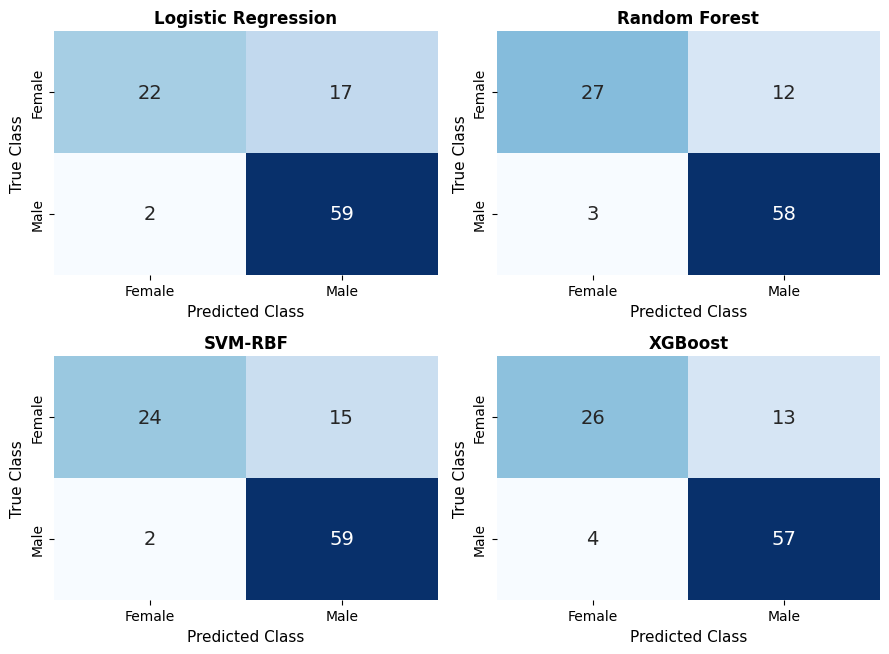

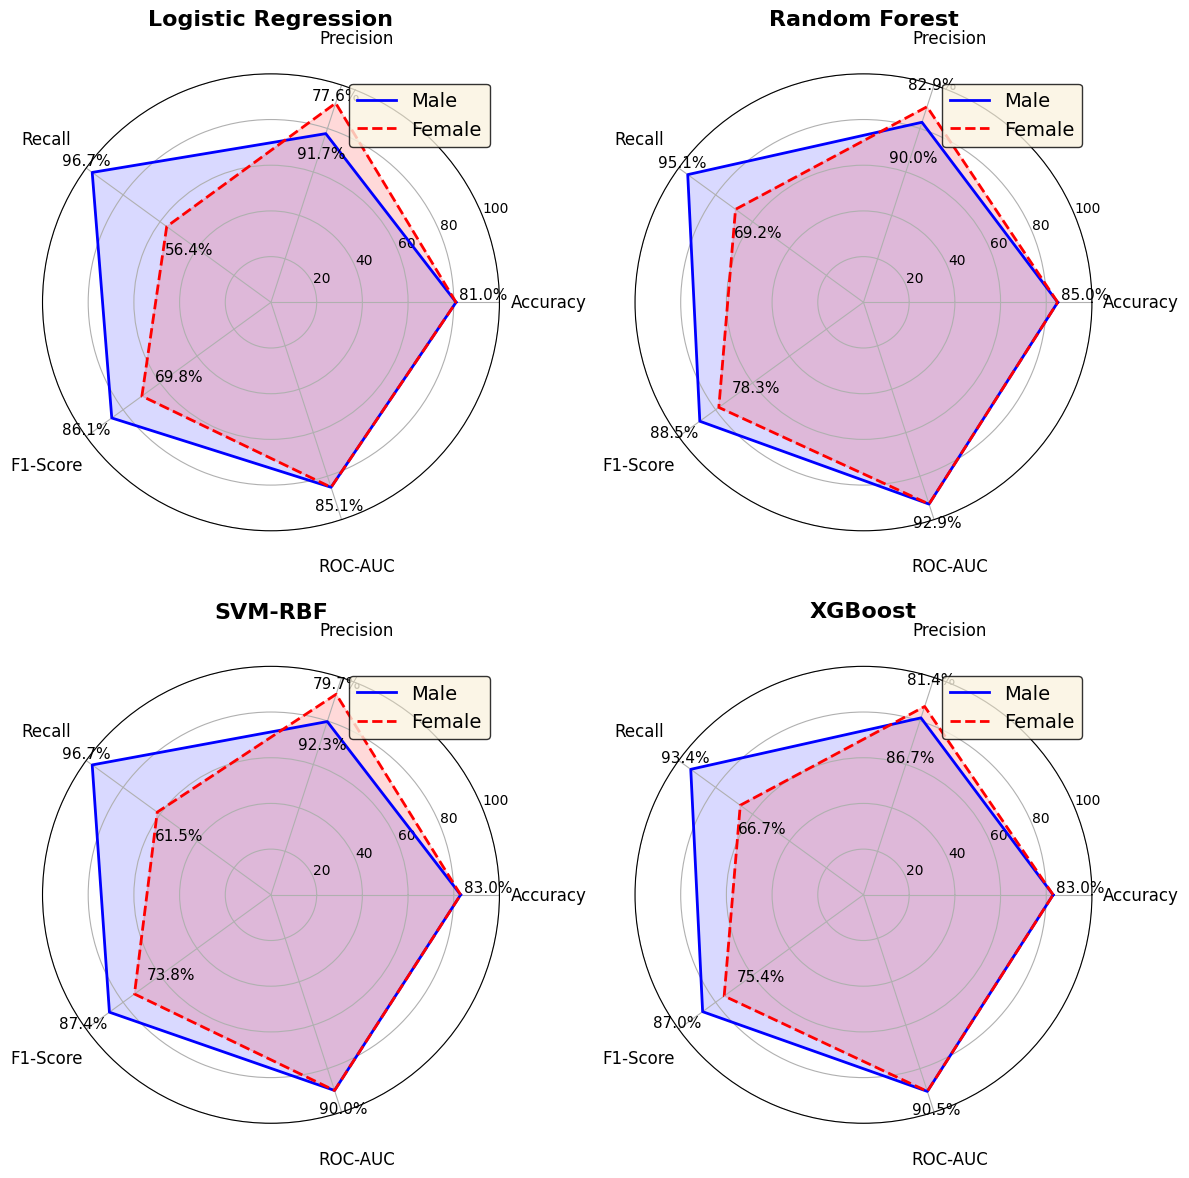


ALL RESULTS SAVED
Results directory:
/content/drive/MyDrive/In-Ovo_Sexing_Duck_Eggs/Features/results/

Files generated:
1. model_selection.csv
2. metrics.csv
3. selected_hyperparameters.csv
4. predictions.csv
5. confusion_matrices.csv
6. confusion_matrices_all_models.png


In [ ]:
import numpy as np
import pandas as pd
import os

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# Bayesian Optimization
from skopt import BayesSearchCV
from skopt.space import Real, Integer

# STEP 0: SETTINGS
RANDOM_STATE = 42
TEST_SIZE = 100
VALIDATION_SIZE = 50

N_ITER = 32
CV_FOLDS = 10

# Bootstrap settings for 95% Confidence Interval
N_BOOTSTRAP = 2000
CONFIDENCE_LEVEL = 0.95

# STEP 1: LOAD DATASET
data_path = ('/content/drive/MyDrive/In-Ovo_Sexing_Duck_Eggs/Features/Morphological_Embryologic_Vascular_Textural_GLCM.csv')
df = pd.read_csv(data_path)

# Ubah kolom Class: F=0, M=1
df['Class'] = df['Class'].map({'F': 0, 'M': 1})

# Simpan Image_Number
image_numbers = df['Image_Number'].values

# Pisahkan fitur dan label
X = df.drop(columns=['Class', 'Image_Number']).values
y = df['Class'].values

# STEP 2: DEVELOPMENT (TEST SPLIT)
# Test set 100 eggs dikunci dan tidak digunakan
# selama training dan hyperparameter optimization.
X_dev, X_test, y_dev, y_test, id_dev, id_test = train_test_split(
    X,
    y,
    image_numbers,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

# STEP 3.1: TRAIN / VALIDATION SPLIT
X_train, X_val, y_train, y_val, id_train, id_val = train_test_split(
    X_dev,
    y_dev,
    id_dev,
    test_size=VALIDATION_SIZE,
    stratify=y_dev,
    random_state=RANDOM_STATE
)
print("\n======================================")
print("DATA SPLIT")
print("======================================")
print(f"Training     : {len(X_train)}")
print(f"Validation   : {len(X_val)}")
print(f"Development  : {len(X_dev)}")
print(f"Testing      : {len(X_test)}")
print(f"Total        : {len(X)}")

# STEP 3.2: VERIFY CLASS DISTRIBUTION
def subset_summary(name, y_subset):
    total = len(y_subset)
    male = np.sum(y_subset == 1)
    female = np.sum(y_subset == 0)
    return {
        'Subset': name,
        'Egg': total,
        'Male': male,
        'Female': female
    }
summary = pd.DataFrame([
    subset_summary('Training', y_train),
    subset_summary('Validation', y_val),
    subset_summary('Development', y_dev),
    subset_summary('Testing', y_test),
    subset_summary('Total', y)
])
print("\nDistribusi kelas per subset:")
print(summary)

# STEP 3.3: SAVE EXACT SPLITS
split_dir = ('/content/drive/MyDrive/In-Ovo_Sexing_Duck_Eggs/Features/splits/')
os.makedirs(split_dir, exist_ok=True)
pd.DataFrame({'Image_Number': id_train
}).to_csv(
    os.path.join(
        split_dir,
        'train_indices.csv'
    ),
    index=False
)

pd.DataFrame({'Image_Number': id_val
}).to_csv(
    os.path.join(
        split_dir,
        'validation_indices.csv'
    ),
    index=False
)

pd.DataFrame({'Image_Number': id_test
}).to_csv(
    os.path.join(
        split_dir,
        'test_indices.csv'
    ),
    index=False
)
print("\nExact split indices saved.")

# STEP 4: DEFINE MODELS
models = {
    'Logistic Regression': {
        'model': LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ),
        'params': {
            'C': Real(
                0.01,
                100,
                prior='log-uniform'
            )
        },
        'scale': True
    },
    'Random Forest': {
        'model': RandomForestClassifier(
            random_state=RANDOM_STATE
        ),
        'params': {
            'n_estimators': Integer(100, 300),
            'max_depth': Integer(3, 10),
            'min_samples_split': Integer(2, 10),
            'min_samples_leaf': Integer(1, 5)
        },
        'scale': False
    },
    'SVM-RBF': {
        'model': SVC(
            kernel='rbf',
            probability=True,
            random_state=RANDOM_STATE
        ),
        'params': {
            'C': Real(
                0.1,
                100,
                prior='log-uniform'
            ),
            'gamma': Real(
                1e-4,
                1e-1,
                prior='log-uniform'
            )
        },
        'scale': True
    },
    'XGBoost': {
        'model': XGBClassifier(
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        'params': {
            'n_estimators': Integer(100, 300),
            'max_depth': Integer(3, 7),

            'learning_rate': Real(
                0.01,
                0.2,
                prior='log-uniform'
            ),
            'subsample': Real(
                0.8,
                1.0
            ),
            'colsample_bytree': Real(
                0.8,
                1.0
            )
        },
        'scale': False
    }
}

# STEP 5.1: BOOTSTRAP CONFIDENCE INTERVAL FUNCTION
def bootstrap_ci(
    y_true,
    y_pred,
    metric_func,
    n_bootstrap=2000,
    confidence=0.95,
    random_state=42
):
    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    scores = []
    n = len(y_true)
    for _ in range(n_bootstrap):
        indices = rng.integers(
            0, n, size=n
        )
        y_true_boot = y_true[indices]
        y_pred_boot = y_pred[indices]

        # -----------------------------------------
        # Lewati sampel bootstrap yang hanya
        # berisi satu kelas karena beberapa
        # metrik tidak dapat dihitung dengan benar.
        # -----------------------------------------
        if len(np.unique(y_true_boot)) < 2:
            continue
        scores.append(metric_func(y_true_boot,y_pred_boot))

    alpha = 1 - confidence
    lower = np.percentile(
        scores,
        100 * (alpha / 2)
    )
    upper = np.percentile(
        scores,
        100 * (1 - alpha / 2)
    )
    return lower, upper

# STEP 5.2: CLASS-SPECIFIC RECALL FUNCTIONS
def female_recall(
    y_true,
    y_pred
):
    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        output_dict=True,
        zero_division=0
    )
    return report['0']['recall']
def male_recall(
    y_true,
    y_pred
):
    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        output_dict=True,
        zero_division=0
    )
    return report['1']['recall']

# STEP 6: BAYESIAN OPTIMIZATION + VALIDATION
selection_results = []
best_parameters = {}
cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

for name, m in models.items():
    print("\n======================================")
    print(f"MODEL: {name}")
    print("======================================")

    # Scaling
    if m['scale']:
        scaler = RobustScaler()
        # Scaler fitted ONLY on training data
        X_tr = scaler.fit_transform(X_train)
        X_v = scaler.transform(X_val)
    else:
        X_tr = X_train
        X_v = X_val

    # Bayesian Optimization
    # ------------------------------------------
    # Hanya data training yang digunakan
    # Data test tetap sepenuhnya tidak disentuh.
    # ------------------------------------------
    bayes = BayesSearchCV(
        estimator=m['model'],
        search_spaces=m['params'],
        cv=cv,
        n_iter=N_ITER,
        scoring='accuracy',
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True,
        verbose=1
    )
    bayes.fit(X_tr, y_train)

    # Best hyperparameters
    best_parameters[name] = bayes.best_params_
    best_model = bayes.best_estimator_

    # Validation evaluation
    y_val_pred = best_model.predict(X_v)
    val_acc = accuracy_score(y_val, y_val_pred)
    print("\nBest parameters:")
    print(bayes.best_params_)
    print(
        f"CV Accuracy: "
        f"{bayes.best_score_ * 100:.2f}%"
    )
    print(
        f"Validation Accuracy: "
        f"{val_acc * 100:.2f}%"
    )

    # Store development results
    selection_results.append({
        'Model': name,
        'CV Accuracy (%)': bayes.best_score_ * 100,
        'Validation Accuracy (%)': val_acc * 100,
        'Best Parameters': str(bayes.best_params_)
    })

# STEP 7: DEVELOPMENT RESULTS
selection_df = pd.DataFrame(selection_results)
print("\n======================================")
print("DEVELOPMENT PERFORMANCE")
print("======================================")
print(selection_df)

# STEP 8: FINAL TRAINING DATA
# -------------------------------------------
# Setelah hyperparameters masing-masing model
# ditentukan menggunakan training data + CV,
# training dan validation digabungkan untuk
# final training masing-masing model.
# -------------------------------------------
X_trainval = np.concatenate(
    [
        X_train,
        X_val
    ],
    axis=0
)

y_trainval = np.concatenate(
    [
        y_train,
        y_val
    ],
    axis=0
)

id_trainval = np.concatenate(
    [
        id_train,
        id_val
    ],
    axis=0
)
print("\n======================================")
print("FINAL TRAINING DATA")
print("======================================")

print(
    f"Training + Validation: "
    f"{len(X_trainval)} eggs"
)

# STEP 9: FINAL TRAINING + FINAL TEST
results = []
all_predictions = []
confusion_matrices = {}
for name, m in models.items():
    print("\n======================================")
    print(f"FINAL MODEL: {name}")
    print("======================================")

    # Final scaling
    if m['scale']:
        final_scaler = RobustScaler()
        # Fit scaler ONLY on Train + Validation
        X_trainval_final = (
            final_scaler.fit_transform(X_trainval)
        )
        # Apply the same scaler to untouched test data
        X_test_final = (
            final_scaler.transform(X_test)
        )
    else:
        X_trainval_final = X_trainval
        X_test_final = X_test

    # Create fresh model
    final_model = m['model']

    # Apply hyperparameters selected
    # during training/CV
    final_model.set_params(
        **best_parameters[name]
    )

    # Train final model
    final_model.fit(X_trainval_final, y_trainval)

    # FINAL TEST EVALUATION
    y_pred = final_model.predict(X_test_final)

    # BASIC PERFORMANCE
    test_acc = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(
        y_test, y_pred
    )
    macro_f1 = f1_score(
        y_test,
        y_pred,
        average='macro'
    )

    # CONFUSION MATRIX
    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    )
    confusion_matrices[name] = cm
    print("\nConfusion Matrix:")
    print(cm)

    # CLASSIFICATION REPORT
    report = classification_report(
        y_test, y_pred,
        labels=[0, 1],
        target_names=[
            'Female',
            'Male'
        ],
        output_dict=True,
        zero_division=0
    )

    # CLASS-SPECIFIC RECALL
    recall_f = report[
        'Female'
    ]['recall']
    recall_m = report[
        'Male'
    ]['recall']

    # FALSE-FEMALE / FALSE-MALE
    # True Male -> Predicted Female
    # This is a false-female decision.
    false_female = cm[1, 0]

    # True Female -> Predicted Male
    # This is a false-male decision.
    false_male = cm[0, 1]

    # ROC-AUC
    if hasattr(final_model, 'predict_proba'):
        y_score = (
            final_model
            .predict_proba(
                X_test_final
            )[:, 1]
        )
    else:
        y_score = (
            final_model
            .decision_function(
                X_test_final
            )
        )
    auc = roc_auc_score(y_test, y_score)

    # 95% BOOTSTRAP CONFIDENCE INTERVALS (CI)
    print("\nCalculating 95% confidence intervals...")

    # Accuracy CI
    acc_ci = bootstrap_ci(
        y_test,
        y_pred,
        accuracy_score,
        n_bootstrap=N_BOOTSTRAP,
        confidence=CONFIDENCE_LEVEL,
        random_state=RANDOM_STATE
    )

    # Balanced Accuracy CI
    balanced_acc_ci = bootstrap_ci(
        y_test,
        y_pred,
        balanced_accuracy_score,
        n_bootstrap=N_BOOTSTRAP,
        confidence=CONFIDENCE_LEVEL,
        random_state=RANDOM_STATE + 1
    )

    # Macro-F1 CI
    macro_f1_ci = bootstrap_ci(
        y_test,
        y_pred,
        lambda yt, yp: f1_score(
            yt,
            yp,
            average='macro'
        ),
        n_bootstrap=N_BOOTSTRAP,
        confidence=CONFIDENCE_LEVEL,
        random_state=RANDOM_STATE + 2
    )

    # Female Recall CI
    female_recall_ci = bootstrap_ci(
        y_test,
        y_pred,
        female_recall,
        n_bootstrap=N_BOOTSTRAP,
        confidence=CONFIDENCE_LEVEL,
        random_state=RANDOM_STATE + 3
    )

    # Male Recall CI
    male_recall_ci = bootstrap_ci(
        y_test,
        y_pred,
        male_recall,
        n_bootstrap=N_BOOTSTRAP,
        confidence=CONFIDENCE_LEVEL,
        random_state=RANDOM_STATE + 4
    )

    # METRICS
    print("\n--------------------------------------")
    print("METRICS")
    print("--------------------------------------")
    print(
        f"Accuracy           : "
        f"{test_acc * 100:.2f}% "
        f"(95% CI: "
        f"{acc_ci[0] * 100:.2f}–"
        f"{acc_ci[1] * 100:.2f}%)"
    )
    print(
        f"Balanced Accuracy  : "
        f"{balanced_acc * 100:.2f}% "
        f"(95% CI: "
        f"{balanced_acc_ci[0] * 100:.2f}–"
        f"{balanced_acc_ci[1] * 100:.2f}%)"
    )
    print(
        f"Macro-F1           : "
        f"{macro_f1 * 100:.2f}% "
        f"(95% CI: "
        f"{macro_f1_ci[0] * 100:.2f}–"
        f"{macro_f1_ci[1] * 100:.2f}%)"
    )
    print(
        f"Female Recall      : "
        f"{recall_f * 100:.2f}% "
        f"(95% CI: "
        f"{female_recall_ci[0] * 100:.2f}–"
        f"{female_recall_ci[1] * 100:.2f}%)"
    )
    print(
        f"Male Recall        : "
        f"{recall_m * 100:.2f}% "
        f"(95% CI: "
        f"{male_recall_ci[0] * 100:.2f}–"
        f"{male_recall_ci[1] * 100:.2f}%)"
    )
    print(
        f"False-Female       : "
        f"{false_female} eggs"
    )
    print(
        f"False-Male         : "
        f"{false_male} eggs"
    )
    print(
        f"ROC-AUC            : "
        f"{auc:.4f}"
    )


    # STORE FINAL TEST RESULTS
    results.append({
        'Model': name,
        # Overall performance
        'Test Accuracy (%)':
            test_acc * 100,
        'Accuracy 95% CI':
            f"{acc_ci[0] * 100:.2f}–"
            f"{acc_ci[1] * 100:.2f}",

        # Balanced accuracy
        'Balanced Accuracy (%)':
            balanced_acc * 100,
        'Balanced Accuracy 95% CI':
            f"{balanced_acc_ci[0] * 100:.2f}–"
            f"{balanced_acc_ci[1] * 100:.2f}",

        'Macro-F1 (%)':
            macro_f1 * 100,
        'Macro-F1 95% CI':
            f"{macro_f1_ci[0] * 100:.2f}–"
            f"{macro_f1_ci[1] * 100:.2f}",

        # Female
        'Precision_F (%)':
            report['Female']['precision'] * 100,
        'Recall_F (%)':
            recall_f * 100,
        'Recall_F 95% CI':
            f"{female_recall_ci[0] * 100:.2f}–"
            f"{female_recall_ci[1] * 100:.2f}",
        'F1_F (%)':
            report['Female']['f1-score'] * 100,

        # Male
        'Precision_M (%)':
            report['Male']['precision'] * 100,
        'Recall_M (%)':
            recall_m * 100,
        'Recall_M 95% CI':
            f"{male_recall_ci[0] * 100:.2f}–"
            f"{male_recall_ci[1] * 100:.2f}",
        'F1_M (%)':
            report['Male']['f1-score'] * 100,

        # Error types
        'False-Female':
            false_female,
        'False-Male':
            false_male,
        # ROC-AUC
        'ROC-AUC':
            auc
    })

    # Store per-sample predictions
    prediction_temp = pd.DataFrame({
        'Image_Number':
            id_test,
        'Model':
            name,
        'True_Class':
            np.where(
                y_test == 0,
                'Female',
                'Male'
            ),
        'Predicted_Class':
            np.where(
                y_pred == 0,
                'Female',
                'Male'
            ),
        'Predicted_Probability_Male':
            y_score
    })
    all_predictions.append(prediction_temp)

# STEP 10: TABLE 5 RESULTS
df_res = pd.DataFrame(results)
print("\n======================================")
print("TABLE 5 - FINAL TEST PERFORMANCE")
print("======================================")
print(df_res.to_string(index=False))

# STEP 11: CONFUSION MATRIX - ALL MODELS
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
axes = axes.flatten()
for ax, (name, cm) in zip(axes,
    confusion_matrices.items()
):
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=[
            'Female',
            'Male'
        ],
        yticklabels=[
            'Female',
            'Male'
        ],
        ax=ax,
        annot_kws={
            'size': 14
        }
    )
    ax.set_title(
        name,
        fontsize=12,
        fontweight='bold'
    )
    ax.set_xlabel(
        'Predicted Class',
        fontsize=11
    )
    ax.set_ylabel(
        'True Class',
        fontsize=11
    )
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# STEP 12: SAVE RESULTS
results_dir = ('/content/drive/MyDrive/In-Ovo_Sexing_Duck_Eggs/Features/results/')
os.makedirs(results_dir, exist_ok=True)

# Development / validation results
# --------------------------------
selection_df.to_csv(
    os.path.join(
        results_dir,
        'model_selection.csv'
    ), index=False
)

# Final Table results
# -------------------
df_res.to_csv(
    os.path.join(
        results_dir,
        'metrics.csv'
    ), index=False
)

# Selected hyperparameters for all four models
hyperparameter_df = pd.DataFrame({
    'Model':
        list(
            best_parameters.keys()
        ),
    'Best_Hyperparameters':
        [
            str(
                best_parameters[name]
            )
            for name in best_parameters
        ]
})
hyperparameter_df.to_csv(
    os.path.join(
        results_dir,
        'selected_hyperparameters.csv'
    ), index=False
)

# Per-sample test predictions
predictions_df = pd.concat(
    all_predictions,
    ignore_index=True
)

predictions_df.to_csv(
    os.path.join(
        results_dir,
        'predictions.csv'
    ), index=False
)

# STEP 13: SAVE CONFUSION MATRICES
# Save numerical confusion matrices
cm_rows = []
for name, cm in confusion_matrices.items():
    cm_rows.append({
        'Model': name,
        'True_Female_Pred_Female':
            cm[0, 0],
        'True_Female_Pred_Male':
            cm[0, 1],
        'True_Male_Pred_Female':
            cm[1, 0],
        'True_Male_Pred_Male':
            cm[1, 1]
    })
cm_df = pd.DataFrame(
    cm_rows
)
cm_df.to_csv(
    os.path.join(
        results_dir,
        'confusion_matrices.csv'
    ), index=False
)

# Save combined confusion matrix figure
fig.savefig(
    os.path.join(
        results_dir,
        'confusion_matrices_all_models.png'
    ),
    dpi=300,
    bbox_inches='tight'
)

# STEP 14: RADAR CHART
metrics = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'ROC-AUC'
]

angles = np.linspace(
    0,
    2 * np.pi,
    len(metrics),
    endpoint=False
).tolist()
angles += angles[:1]
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 12),
    subplot_kw=dict(
        polar=True
    )
)
axes = axes.flatten()
for idx, row in df_res.iterrows():
    acc_val = row[
        'Test Accuracy (%)'
    ]

    auc_val = row[
        'ROC-AUC'
    ] * 100
    vals_f = [
        acc_val,
        row['Precision_F (%)'],
        row['Recall_F (%)'],
        row['F1_F (%)'],
        auc_val
    ]
    vals_m = [
        acc_val,
        row['Precision_M (%)'],
        row['Recall_M (%)'],
        row['F1_M (%)'],
        auc_val
    ]
    vals_f += vals_f[:1]
    vals_m += vals_m[:1]
    ax = axes[idx]
    ax.plot(
        angles,
        vals_m,
        label='Male',
        color='blue',
        linewidth=2
    )
    ax.fill(
        angles,
        vals_m,
        alpha=0.15,
        color='blue'
    )
    ax.plot(
        angles,
        vals_f,
        label='Female',
        color='red',
        linestyle='--',
        linewidth=2
    )
    ax.fill(
        angles,
        vals_f,
        alpha=0.15,
        color='red'
    )
    ax.set_xticks(
        angles[:-1]
    )
    ax.set_xticklabels(
        metrics,
        fontsize=12
    )
    ax.tick_params(
        pad=25
    )
    ax.set_ylim(
        0, 100
    )

    ax.set_title(
        row['Model'],
        size=16,
        pad=35,
        fontweight='bold'
    )

    legend = ax.legend(
        loc='upper right',
        fontsize=14,
        frameon=True
    )
    legend.get_frame().set_facecolor('#FAF3E0')
    legend.get_frame().set_edgecolor('black')

    # Add performance values
    for metric, angle, val_m, val_f in zip(
        metrics,
        angles[:-1],
        vals_m[:-1],
        vals_f[:-1]
    ):
        if metric in [
            'Accuracy',
            'ROC-AUC'
        ]:
            ax.text(
                angle,
                val_m + 12,
                f"{val_m:.1f}%",
                color='black',
                ha='center',
                va='bottom',
                fontsize=11
            )

        elif metric == 'Precision':
            ax.text(
                angle,
                val_m + 14,
                f"{val_m:.1f}%",
                color='black',
                ha='center',
                va='bottom',
                fontsize=11
            )
            ax.text(
                angle,
                val_f - 20,
                f"{val_f:.1f}%",
                color='black',
                ha='center',
                va='top',
                fontsize=11
            )
        elif metric == 'Recall':
            ax.text(
                angle,
                val_m + 3,
                f"{val_m:.1f}%",
                color='black',
                ha='center',
                va='bottom',
                fontsize=11
            )
            ax.text(
                angle,
                val_f - 12,
                f"{val_f:.1f}%",
                color='black',
                ha='center',
                va='top',
                fontsize=11
            )

        else:
            ax.text(
                angle,
                val_m + 14,
                f"{val_m:.1f}%",
                color='black',
                ha='center',
                va='bottom',
                fontsize=11
            )

            ax.text(
                angle,
                val_f - 20,
                f"{val_f:.1f}%",
                color='black',
                ha='center',
                va='top',
                fontsize=11
            )
plt.tight_layout()
plt.show()

# STEP 15: FINAL OUTPUT LOCATION
print("\n======================================")
print("ALL RESULTS SAVED")
print("======================================")
print(
    f"Results directory:\n"
    f"{results_dir}"
)
print("\nFiles generated:")
print("1. model_selection.csv")
print("2. metrics.csv")
print("3. selected_hyperparameters.csv")
print("4. predictions.csv")
print("5. confusion_matrices.csv")
print("6. confusion_matrices_all_models.png")

**4. Eksperimen Tambahan: Batch-Held-Out Evaluation**


BATCH-HELD-OUT DATASET
Total eggs : 503

Columns:
['Image_Number', 'Length', 'Width', 'Shape_Index', 'Weight', 'Eccentricity', 'Perimeter', 'Sinus_Terminalis_Area', 'Embryo_Vascular_Area', 'Fractal_Dimension', 'Branch_Nodes', 'GLCM_Energy', 'GLCM_Contrast', 'GLCM_Correlation', 'GLCM_Homogeneity', 'GLCM_Entropy', 'Class', 'Acquisition_Stage']

ACQUISITION STAGE DISTRIBUTION
Class              Female  Male  Total
Acquisition_Stage                     
Stage 1                98   134    232
Stage 2                96   175    271


ORIGINAL RANDOM SPLIT DISTRIBUTION
Acquisition_Stage     Subset  Female  Male  Total
          Stage 1   Training      70    94    164
          Stage 2   Training      66   123    189
          Stage 1 Validation      11    20     31
          Stage 2 Validation       8    11     19
          Stage 1       Test      17    20     37
          Stage 2       Test      22    41     63

Original split sizes:
Training     : 353
Validation   : 50
Development  : 403
T

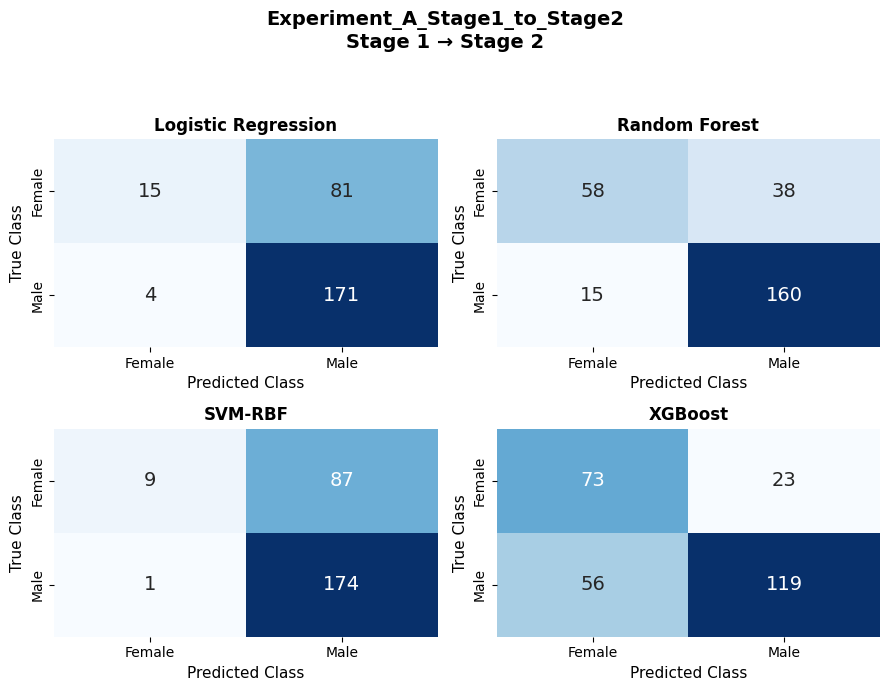


BATCH-HELD-OUT DATA DISTRIBUTION

                   Experiment Acquisition_Stage           Subset  Female  Male  Total
Experiment_A_Stage1_to_Stage2           Stage 1         Training      78   107    185
Experiment_A_Stage1_to_Stage2           Stage 1       Validation      20    27     47
Experiment_A_Stage1_to_Stage2           Stage 2 Independent Test      96   175    271

BATCH-HELD-OUT FINAL PERFORMANCE

                   Experiment Training_Stage Independent_Test_Stage               Model  Training_N  Independent_Test_N  Test_Accuracy (%)  Balanced_Accuracy (%)  Macro_F1 (%)  Recall_F (%)  Recall_M (%)  False-Female  False-Male  ROC-AUC
Experiment_A_Stage1_to_Stage2        Stage 1                Stage 2 Logistic Regression         232                 271            68.6347                56.6696       53.0903       15.6250       97.7143             4          81   0.7674
Experiment_A_Stage1_to_Stage2        Stage 1                Stage 2       Random Forest         232         

In [ ]:
# EXPERIMENT: BATCH-HELD-OUT EVALUATION
# Experiment A Only
# Early In-Ovo Sexing of Duck Eggs

# Stage 1 -> Training + Validation
# Stage 2 -> Independent Test
# --------------------------------------

import numpy as np
import pandas as pd
import os
import warnings

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Bayesian Optimization
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.base import clone
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# SETTINGS
RANDOM_STATE = 42
N_ITER = 32
CV_FOLDS = 10

# Internal validation fraction
VALIDATION_FRACTION = 0.20

# Bootstrap settings for 95% Confidence Interval
N_BOOTSTRAP = 2000
CONFIDENCE_LEVEL = 0.95

data_path = ('/content/drive/MyDrive/In-Ovo_Sexing_Duck_Eggs/Features/Morphological_Embryologic_Vascular_Textural_GLCM.csv')
acquisition_stage_path = ('/content/drive/MyDrive/In-Ovo_Sexing_Duck_Eggs/Features/Acquisition_Stage.csv')
results_dir = ('/content/drive/MyDrive/In-Ovo_Sexing_Duck_Eggs/Features/results/batch_held_out/')
os.makedirs(results_dir, exist_ok=True)
df = pd.read_csv(data_path)
acquisition_stage_df = pd.read_csv(acquisition_stage_path)
df = df.merge(
    acquisition_stage_df[
        ['Image_Number', 'Acquisition_Stage']
    ],
    on='Image_Number',
    how='left',
    validate='one_to_one'
)

# DATA CHECK
print("\n======================================")
print("BATCH-HELD-OUT DATASET")
print("======================================")
print(f"Total eggs : {len(df)}")
print("\nColumns:")
print(df.columns.tolist())

# LABEL ENCODING
# F = Female = 0
# M = Male   = 1
df['Class'] = df['Class'].map({
    'F': 0,
    'M': 1
})

# FEATURE LIST
features = [
    'Length',
    'Width',
    'Shape_Index',
    'Weight',
    'Eccentricity',

    'Perimeter',
    'Sinus_Terminalis_Area',
    'Embryo_Vascular_Area',
    'Fractal_Dimension',
    'Branch_Nodes',

    'GLCM_Energy',
    'GLCM_Contrast',
    'GLCM_Correlation',
    'GLCM_Homogeneity',
    'GLCM_Entropy'
]

# CHECK REQUIRED COLUMNS
required_columns = (
    [
        'Image_Number',
        'Acquisition_Stage',
        'Class'
    ]
    + features
)

missing_columns = [
    col
    for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}"
    )

# REMOVE MISSING VALUES
df = df.dropna(subset=required_columns).reset_index(drop=True)

# CHECK ACQUISITION STAGE
print("\n======================================")
print("ACQUISITION STAGE DISTRIBUTION")
print("======================================")

stage_class_summary = pd.crosstab(
    df['Acquisition_Stage'], df['Class']
)

stage_class_summary = (
    stage_class_summary
    .rename(
        columns={
            0: 'Female',
            1: 'Male'
        }
    )
)

if 'Female' not in stage_class_summary.columns:
    stage_class_summary['Female'] = 0
if 'Male' not in stage_class_summary.columns:
    stage_class_summary['Male'] = 0
stage_class_summary['Total'] = (
    stage_class_summary['Female']
    + stage_class_summary['Male']
)
stage_class_summary = (stage_class_summary
    [['Female', 'Male', 'Total']]
)
print(stage_class_summary.to_string())

# SAVE STAGE DISTRIBUTION
stage_class_summary.to_csv(
    os.path.join(
        results_dir,
        'acquisition_stage_class_distribution.csv'
    )
)

# ORIGINAL RANDOM SPLIT DISTRIBUTION
# IMPORTANT:
# This section is NOT the batch-held-out experiment.
# It documents how Stage 1 and Stage 2 were distributed
# in the original random 353/50/100 split.

print("\n")
print("=" * 80)
print("ORIGINAL RANDOM SPLIT DISTRIBUTION")
print("=" * 80)

# Original settings
TEST_SIZE_ORIGINAL = 100
VALIDATION_SIZE_ORIGINAL = 50

# Data
X_original = (df[features] .values)
y_original = (df['Class'] .values)
id_original = (df['Image_Number'] .values)
stage_original = (df['Acquisition_Stage'] .values)

# Development / Test split
(
    X_dev,
    X_test_original,
    y_dev,
    y_test_original,
    id_dev,
    id_test_original,
    stage_dev,
    stage_test_original
) = train_test_split(

    X_original,
    y_original,
    id_original,
    stage_original,
    test_size=TEST_SIZE_ORIGINAL,
    stratify=y_original,
    random_state=RANDOM_STATE
)

# Training / Validation split
(
    X_train_original,
    X_val_original,
    y_train_original,
    y_val_original,
    id_train_original,
    id_val_original,
    stage_train_original,
    stage_val_original
) = train_test_split(

    X_dev,
    y_dev,
    id_dev,
    stage_dev,
    test_size=VALIDATION_SIZE_ORIGINAL,
    stratify=y_dev,
    random_state=RANDOM_STATE
)

# Function
def original_split_stage_summary(
    subset_name,
    stage_array,
    y_array
):
    temp = pd.DataFrame({
        'Acquisition_Stage':
            stage_array,
        'Class':
            y_array
    })
    table = pd.crosstab(
        temp['Acquisition_Stage'],
        temp['Class']
    )
    table = (
        table
        .rename(
            columns={
                0: 'Female',
                1: 'Male'
            }
        )
    )

    if 'Female' not in table.columns:
        table['Female'] = 0
    if 'Male' not in table.columns:
        table['Male'] = 0
    table['Total'] = (
        table['Female']
        + table['Male']
    )
    table.insert(
        0,
        'Subset',
        subset_name
    )
    return table.reset_index()

# Create summary
original_split_summary = pd.concat(
    [
        original_split_stage_summary(
            'Training',
            stage_train_original,
            y_train_original
        ),

        original_split_stage_summary(
            'Validation',
            stage_val_original,
            y_val_original
        ),

        original_split_stage_summary(
            'Test',
            stage_test_original,
            y_test_original
        )
    ],
    ignore_index=True
)

print(original_split_summary.to_string(index=False))

# Save original split distribution
original_split_summary.to_csv(
    os.path.join(
        results_dir,
        'original_random_split_stage_distribution.csv'
    ),
    index=False
)

print("\nOriginal split sizes:")
print(
    f"Training     : {len(X_train_original)}\n"
    f"Validation   : {len(X_val_original)}\n"
    f"Development  : {len(X_dev)}\n"
    f"Testing      : {len(X_test_original)}\n"
    f"Total        : {len(X_original)}"
)

# DEFINE MODELS
models = {
    # LOGISTIC REGRESSION
    'Logistic Regression': {
        'model': Pipeline([
            (
                'scaler',
                RobustScaler()
            ),

            (
                'model',
                LogisticRegression(
                    max_iter=1000,
                    random_state=RANDOM_STATE
                )
            )

        ]),

        'params': {
            'model__C': Real(
                0.01,
                100,
                prior='log-uniform'
            )
        }
    },

    # RANDOM FOREST
    'Random Forest': {
        'model': Pipeline([
            (
                'model',
                RandomForestClassifier(
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                )
            )

        ]),

        'params': {
            'model__n_estimators':
                Integer(100, 300),
            'model__max_depth':
                Integer(3, 10),
            'model__min_samples_split':
                Integer(2, 10),
            'model__min_samples_leaf':
                Integer(1, 5)
        }
    },

    # SVM-RBF
    'SVM-RBF': {
        'model': Pipeline([
            (
                'scaler',
                RobustScaler()
            ),

            (
                'model',
                SVC(
                    kernel='rbf',
                    probability=True,
                    random_state=RANDOM_STATE
                )
            )

        ]),

        'params': {
            'model__C': Real(
                0.1,
                100,
                prior='log-uniform'
            ),
            'model__gamma': Real(
                1e-4,
                1e-1,
                prior='log-uniform'
            )
        }
    },

    # XGBOOST
    'XGBoost': {
        'model': Pipeline([
            (
                'model',
                XGBClassifier(
                    eval_metric='logloss',
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                )
            )

        ]),

        'params': {

            'model__n_estimators':
                Integer(100, 300),

            'model__max_depth':
                Integer(3, 7),

            'model__learning_rate':
                Real(
                    0.01,
                    0.2,
                    prior='log-uniform'
                ),

            'model__subsample':
                Real(
                    0.8,
                    1.0
                ),

            'model__colsample_bytree':
                Real(
                    0.8,
                    1.0
                )
        }
    }
}

# CROSS-VALIDATION
cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# BOOTSTRAP CONFIDENCE INTERVAL
def bootstrap_ci(
    y_true,
    y_pred,
    metric_func,
    n_bootstrap=2000,
    confidence=0.95,
    random_state=42
):
    rng = np.random.default_rng(
        random_state
    )

    y_true = np.asarray(
        y_true
    )

    y_pred = np.asarray(
        y_pred
    )

    scores = []
    n = len(y_true)

    for _ in range(
        n_bootstrap
    ):

        indices = rng.integers(
            0,
            n,
            size=n
        )

        y_true_boot = (
            y_true[indices]
        )

        y_pred_boot = (
            y_pred[indices]
        )

        if len(
            np.unique(
                y_true_boot
            )
        ) < 2:
            continue

        try:
            score = metric_func(
                y_true_boot,
                y_pred_boot
            )

            scores.append(
                score
            )

        except Exception:
            continue

    alpha = (
        1 - confidence
    )

    lower = np.percentile(
        scores,
        100 * (
            alpha / 2
        )
    )

    upper = np.percentile(
        scores,
        100 * (
            1 - alpha / 2
        )
    )

    return lower, upper


# CLASS-SPECIFIC RECALL
def female_recall(
    y_true,
    y_pred
):

    return recall_score(
        y_true,
        y_pred,
        labels=[0],
        average='macro',
        zero_division=0
    )


def male_recall(
    y_true,
    y_pred
):
    return recall_score(
        y_true,
        y_pred,
        labels=[1],
        average='macro',
        zero_division=0
    )


# BATCH-HELD-OUT FUNCTION
def run_batch_held_out(
    data,
    training_stage,
    testing_stage,
    experiment_name
):

    print("\n\n")
    print("=" * 80)
    print(experiment_name)
    print("=" * 80)

    # EXPLICIT EXPERIMENT DESIGN
    print(
        "\nEXPERIMENT DESIGN\n"
        f"Training / Validation : {training_stage}\n"
        f"Independent Test      : {testing_stage}"
    )

    # SELECT TRAINING STAGE
    development_df = data[
        data['Acquisition_Stage']
        == training_stage
    ].copy()

    # SELECT INDEPENDENT TEST STAGE
    test_df = data[
        data['Acquisition_Stage']
        == testing_stage
    ].copy()

    # X / y
    X_stage = (
        development_df[
            features
        ].values
    )

    y_stage = (
        development_df[
            'Class'
        ].values
    )

    id_stage = (
        development_df[
            'Image_Number'
        ].values
    )

    X_test = (
        test_df[
            features
        ].values
    )

    y_test = (
        test_df[
            'Class'
        ].values
    )

    id_test = (
        test_df[
            'Image_Number'
        ].values
    )

    # STAGE DISTRIBUTION
    print(
        "\n======================================\n"
        f"{training_stage} : DEVELOPMENT\n"
        "======================================"
    )

    development_class = (
        development_df[
            'Class'
        ]
        .map({
            0: 'Female',
            1: 'Male'
        })
        .value_counts()
    )

    print(development_class)
    print(
        f"Total : "
        f"{len(development_df)}"
    )

    print(
      "\n======================================\n"
      f"{testing_stage} : INDEPENDENT TEST\n"
      "======================================"
    )

    test_class = (
        test_df[
            'Class'
        ]
        .map({
            0: 'Female',
            1: 'Male'
        })
        .value_counts()
    )

    print(test_class)
    print(
        f"Total : "
        f"{len(test_df)}"
    )

    # INTERNAL TRAIN / VALIDATION SPLIT
    # IMPORTANT:
    # Only the training stage is split.
    # The independent test stage remains completely untouched.

    (
        X_train,
        X_val,
        y_train,
        y_val,
        id_train,
        id_val
    ) = train_test_split(
        X_stage,
        y_stage,
        id_stage,
        test_size=VALIDATION_FRACTION,
        stratify=y_stage,
        random_state=RANDOM_STATE
    )

    # EXPLICIT SPLIT TABLE
    split_table = []

    def split_class_counts(
        stage_name,
        subset_name,
        y_subset
    ):
        female = np.sum(
            y_subset == 0
        )
        male = np.sum(
            y_subset == 1
        )
        total = len(
            y_subset
        )
        return {
            'Experiment':
                experiment_name,
            'Acquisition_Stage':
                stage_name,
            'Subset':
                subset_name,
            'Female':
                female,
            'Male':
                male,
            'Total':
                total
        }

    # Training stage
    split_table.append(
        split_class_counts(
            training_stage,
            'Training',
            y_train
        )
    )

    split_table.append(
        split_class_counts(
            training_stage,
            'Validation',
            y_val
        )
    )

    # Independent test stage
    split_table.append(
        split_class_counts(
            testing_stage,
            'Independent Test',
            y_test
        )
    )

    split_df = pd.DataFrame(split_table)

    # PRINT EXACT EXPERIMENT DESIGN
    print("\n")
    print("=" * 80)
    print(
        f"{experiment_name} - DATA DISTRIBUTION"
    )
    print("=" * 80)

    print(
        split_df[
            [
                'Acquisition_Stage',
                'Subset',
                'Female',
                'Male',
                'Total'
            ]
        ].to_string(
            index=False
        )
    )

    # SAVE SPLIT TABLE
    split_df.to_csv(
        os.path.join(
            results_dir,
            f'{experiment_name}_data_distribution.csv'
        ),
        index=False
    )

    # VERIFY NO OVERLAP
    train_ids_set = set(id_train)
    val_ids_set = set(id_val)
    test_ids_set = set(id_test)

    assert (
        train_ids_set
        .isdisjoint(
            val_ids_set
        )
    )

    assert (
        train_ids_set
        .isdisjoint(
            test_ids_set
        )
    )

    assert (
        val_ids_set
        .isdisjoint(
            test_ids_set
        )
    )

    print("\n")
    print(
        "CHECK: No Image_Number overlap "
        "between Training, Validation, "
        "and Independent Test."
    )

    # MODEL RESULTS
    results = []
    all_predictions = []
    confusion_matrices = {}
    best_parameters = {}

    # MODEL LOOP
    for name, m in models.items():

        print(
            "\n" + "-" * 70 + "\n"
            f"MODEL: {name}\n"
            + "-" * 70
        )

        # BAYESIAN OPTIMIZATION
        # ONLY TRAINING DATA
        bayes = BayesSearchCV(
            estimator=clone(
                m['model']
            ),

            search_spaces=m['params'],
            cv=cv,
            n_iter=N_ITER,
            scoring='accuracy',
            n_jobs=-1,
            random_state=RANDOM_STATE,
            refit=True,
            verbose=1
        )

        bayes.fit(
            X_train,
            y_train
        )

        # BEST PARAMETERS
        best_parameters[name] = (bayes.best_params_)
        best_model = (bayes.best_estimator_)

        print("\nBest parameters:")
        print(
            bayes.best_params_
        )

        print(
            f"\nCV Accuracy: "
            f"{bayes.best_score_ * 100:.2f}%"
        )

        # INTERNAL VALIDATION
        y_val_pred = (
            best_model.predict(
                X_val
            )
        )

        validation_accuracy = (
            accuracy_score(
                y_val,
                y_val_pred
            )
        )

        validation_balanced_accuracy = (
            balanced_accuracy_score(
                y_val,
                y_val_pred
            )
        )

        validation_macro_f1 = (
            f1_score(
                y_val,
                y_val_pred,
                average='macro',
                zero_division=0
            )
        )

        print(
            f"Validation Accuracy: "
            f"{validation_accuracy * 100:.2f}%"
        )

        # FINAL TRAINING
        # Training + Validation are combined AFTER
        # hyperparameters have been determined.
        # Independent test stage remains untouched.

        X_trainval = np.concatenate(
            [
                X_train,
                X_val
            ],
            axis=0
        )

        y_trainval = np.concatenate(
            [
                y_train,
                y_val
            ],
            axis=0
        )

        # Fresh model
        final_model = clone(m['model'])

        final_model.set_params(
            **best_parameters[name]
        )

        # Final fit
        final_model.fit(
            X_trainval,
            y_trainval
        )

        # INDEPENDENT TEST
        # testing_stage has never been used for:
        # - training
        # - validation
        # - CV
        # - hyperparameter optimization

        y_pred = (
            final_model.predict(
                X_test
            )
        )

        # BASIC PERFORMANCE
        test_accuracy = (
            accuracy_score(
                y_test,
                y_pred
            )
        )

        balanced_accuracy = (
            balanced_accuracy_score(
                y_test,
                y_pred
            )
        )

        macro_f1 = (
            f1_score(
                y_test,
                y_pred,
                average='macro',
                zero_division=0
            )
        )

        macro_precision = (
            precision_score(
                y_test,
                y_pred,
                average='macro',
                zero_division=0
            )
        )

        macro_recall = (
            recall_score(
                y_test,
                y_pred,
                average='macro',
                zero_division=0
            )
        )

        # CONFUSION MATRIX
        cm = confusion_matrix(
            y_test,
            y_pred,
            labels=[0, 1]
        )

        confusion_matrices[name] = cm

        print("\nConfusion Matrix:")
        print(cm)

        # CLASSIFICATION REPORT
        report = classification_report(
            y_test,
            y_pred,
            labels=[
                0,
                1
            ],

            target_names=[
                'Female',
                'Male'
            ],
            output_dict=True,
            zero_division=0
        )

        # FEMALE METRICS
        precision_f = (
            report[
                'Female'
            ]['precision']
        )

        recall_f = (
            report[
                'Female'
            ]['recall']
        )

        f1_f = (
            report[
                'Female'
            ]['f1-score']
        )

        # MALE METRICS
        precision_m = (
            report[
                'Male'
            ]['precision']
        )

        recall_m = (
            report[
                'Male'
            ]['recall']
        )

        f1_m = (
            report[
                'Male'
            ]['f1-score']
        )

        # ERROR TYPES
        # True Male -> Predicted Female
        false_female = cm[1, 0]

        # True Female -> Predicted Male
        false_male = cm[0, 1]

        # ROC-AUC
        if hasattr(
            final_model,
            'predict_proba'
        ):

            y_score = (
                final_model
                .predict_proba(
                    X_test
                )[:, 1]
            )

        else:

            y_score = (
                final_model
                .decision_function(
                    X_test
                )
            )

        auc = roc_auc_score(
            y_test,
            y_score
        )

        # BOOTSTRAP CONFIDENCE INTERVALS
        print(
            "\nCalculating 95% confidence intervals..."
        )

        # Accuracy
        acc_ci = bootstrap_ci(
            y_test,
            y_pred,
            accuracy_score,
            N_BOOTSTRAP,
            CONFIDENCE_LEVEL,
            RANDOM_STATE
        )

        # Balanced Accuracy
        balanced_acc_ci = bootstrap_ci(
            y_test,
            y_pred,
            balanced_accuracy_score,
            N_BOOTSTRAP,
            CONFIDENCE_LEVEL,
            RANDOM_STATE + 1
        )

        # Macro-F1
        macro_f1_ci = bootstrap_ci(
            y_test,
            y_pred,
            lambda yt, yp:
                f1_score(
                    yt,
                    yp,
                    average='macro',
                    zero_division=0
                ),

            N_BOOTSTRAP,
            CONFIDENCE_LEVEL,
            RANDOM_STATE + 2
        )

        # Female Recall
        female_recall_ci = bootstrap_ci(
            y_test,
            y_pred,
            female_recall,
            N_BOOTSTRAP,
            CONFIDENCE_LEVEL,
            RANDOM_STATE + 3
        )

        # Male Recall
        male_recall_ci = bootstrap_ci(
            y_test,
            y_pred,
            male_recall,
            N_BOOTSTRAP,
            CONFIDENCE_LEVEL,
            RANDOM_STATE + 4
        )

        # PRINT FINAL RESULTS
        print(
            "\n" + "=" * 60 + "\n"
            "INDEPENDENT BATCH TEST RESULTS\n"
            + "=" * 60 + "\n"
            f"Training / Validation : {training_stage}\n"
            f"Independent Test      : {testing_stage}\n\n"
            f"Accuracy          : {test_accuracy * 100:.2f}% "
            f"(95% CI: {acc_ci[0] * 100:.2f}–{acc_ci[1] * 100:.2f}%)\n"
            f"Balanced Accuracy : {balanced_accuracy * 100:.2f}% "
            f"(95% CI: {balanced_acc_ci[0] * 100:.2f}–{balanced_acc_ci[1] * 100:.2f}%)\n"
            f"Macro-F1          : {macro_f1 * 100:.2f}% "
            f"(95% CI: {macro_f1_ci[0] * 100:.2f}–{macro_f1_ci[1] * 100:.2f}%)\n"
            f"Female Recall     : {recall_f * 100:.2f}% "
            f"(95% CI: {female_recall_ci[0] * 100:.2f}–{female_recall_ci[1] * 100:.2f}%)\n"
            f"Male Recall       : {recall_m * 100:.2f}% "
            f"(95% CI: {male_recall_ci[0] * 100:.2f}–{male_recall_ci[1] * 100:.2f}%)\n"
            f"False-Female      : {false_female} eggs\n"
            f"False-Male        : {false_male} eggs\n"
            f"ROC-AUC           : {auc:.4f}"
        )

        # STORE RESULTS
        results.append({
            'Experiment':
                experiment_name,
            'Training_Stage':
                training_stage,
            'Independent_Test_Stage':
                testing_stage,
            'Training_N':
                len(X_trainval),
            'Independent_Test_N':
                len(X_test),
            'Model':
                name,

            # Model selection
            'CV_Accuracy (%)':
                bayes.best_score_ * 100,
            'Validation_Accuracy (%)':
                validation_accuracy * 100,
            'Validation_Balanced_Accuracy (%)':
                validation_balanced_accuracy * 100,
            'Validation_Macro_F1 (%)':
                validation_macro_f1 * 100,

            # Independent test
            'Test_Accuracy (%)':
                test_accuracy * 100,
            'Accuracy_95CI':
                (
                    f"{acc_ci[0] * 100:.2f}–"
                    f"{acc_ci[1] * 100:.2f}"
                ),

            'Balanced_Accuracy (%)':
                balanced_accuracy * 100,
            'Balanced_Accuracy_95CI':
                (
                    f"{balanced_acc_ci[0] * 100:.2f}–"
                    f"{balanced_acc_ci[1] * 100:.2f}"
                ),

            'Macro_Precision (%)':
                macro_precision * 100,
            'Macro_Recall (%)':
                macro_recall * 100,
            'Macro_F1 (%)':
                macro_f1 * 100,
            'Macro_F1_95CI':
                (
                    f"{macro_f1_ci[0] * 100:.2f}–"
                    f"{macro_f1_ci[1] * 100:.2f}"
                ),

            # Female
            'Precision_F (%)':
                precision_f * 100,
            'Recall_F (%)':
                recall_f * 100,
            'Recall_F_95CI':
                (
                    f"{female_recall_ci[0] * 100:.2f}–"
                    f"{female_recall_ci[1] * 100:.2f}"
                ),
            'F1_F (%)':
                f1_f * 100,

            # Male
            'Precision_M (%)':
                precision_m * 100,
            'Recall_M (%)':
                recall_m * 100,
            'Recall_M_95CI':
                (
                    f"{male_recall_ci[0] * 100:.2f}–"
                    f"{male_recall_ci[1] * 100:.2f}"
                ),
            'F1_M (%)':
                f1_m * 100,

            # Error types
            'False-Female':
                false_female,
            'False-Male':
                false_male,

            # ROC-AUC
             'ROC-AUC':
                auc,

            # Confusion Matrix
            'TN':
                cm[0, 0],
            'FP':
                cm[0, 1],
            'FN':
                cm[1, 0],
            'TP':
                cm[1, 1]
        })

        # PER-SAMPLE PREDICTIONS
        prediction_temp = pd.DataFrame({
            'Experiment':
                experiment_name,
            'Training_Stage':
                training_stage,
            'Independent_Test_Stage':
                testing_stage,
            'Image_Number':
                id_test,
            'Model':
                name,
            'True_Class':
                np.where(
                    y_test == 0,
                    'Female',
                    'Male'
                ),
            'Predicted_Class':
                np.where(
                    y_pred == 0,
                    'Female',
                    'Male'
                ),
            'Predicted_Probability_Male':
                y_score
        })

        all_predictions.append(
            prediction_temp
        )

    # SAVE EXPERIMENT RESULTS
    experiment_results_df = (
        pd.DataFrame(
            results
        )
    )

    experiment_predictions_df = (
        pd.concat(
            all_predictions,
            ignore_index=True
        )
    )

    experiment_results_df.to_csv(
        os.path.join(
            results_dir,
            f'{experiment_name}_metrics.csv'
        ),
        index=False
    )

    experiment_predictions_df.to_csv(
        os.path.join(
            results_dir,
            f'{experiment_name}_predictions.csv'
        ),
        index=False
    )


    # SAVE HYPERPARAMETERS
    hyperparameter_df = pd.DataFrame({
        'Model':
            list(
                best_parameters.keys()
            ),
        'Best_Hyperparameters':

            [
                str(
                    best_parameters[name]
                )
                for name
                in best_parameters
            ]
    })

    hyperparameter_df.to_csv(
        os.path.join(
            results_dir,
            f'{experiment_name}_hyperparameters.csv'
        ),
        index=False
    )

    # SAVE CONFUSION MATRICES
    cm_rows = []

    for name, cm in (
        confusion_matrices.items()
    ):

        cm_rows.append({
            'Experiment':
                experiment_name,
            'Training_Stage':
                training_stage,
            'Independent_Test_Stage':
                testing_stage,
            'Model':
                name,
            'True_Female_Pred_Female':
                cm[0, 0],
            'True_Female_Pred_Male':
                cm[0, 1],
            'True_Male_Pred_Female':
                cm[1, 0],
            'True_Male_Pred_Male':
                cm[1, 1]
        })

    cm_df = pd.DataFrame(
        cm_rows
    )


    cm_df.to_csv(
        os.path.join(
            results_dir,
            f'{experiment_name}_confusion_matrices.csv'
        ),
        index=False
    )



    # CONFUSION MATRIX FIGURE
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(9, 7)
    )

    axes = axes.flatten()

    for ax, (name, cm) in zip(
        axes,
        confusion_matrices.items()
    ):

        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            cbar=False,
            xticklabels=[
                'Female',
                'Male'
            ],

            yticklabels=[
                'Female',
                'Male'
            ],

            ax=ax,
            annot_kws={
                'size': 14
            }
        )

        ax.set_title(
            name,
            fontsize=12,
            fontweight='bold'
        )

        ax.set_xlabel(
            'Predicted Class',
            fontsize=11
        )


        ax.set_ylabel(
            'True Class',
            fontsize=11
        )


    fig.suptitle(
        (
            f'{experiment_name}\n'
            f'{training_stage} → '
            f'{testing_stage}'
        ),
        fontsize=14,
        fontweight='bold'
    )


    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.93
        ]
    )


    fig.savefig(
        os.path.join(
            results_dir,
            f'{experiment_name}_confusion_matrices.png'
        ),
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


    # RETURN
    return (
        experiment_results_df,
        experiment_predictions_df,
        cm_df,
        split_df
    )


# EXPERIMENT A ONLY
# Stage 1 → Training
# Stage 1 → Validation
# Stage 2 → Independent Test
results_A, predictions_A, cm_A, split_A = (
    run_batch_held_out(
        data=df,
        training_stage='Stage 1',
        testing_stage='Stage 2',
        experiment_name=(
            'Experiment_A_Stage1_to_Stage2'
        )
    )
)


# FINAL DATA DISTRIBUTION TABLE
print(
    "\n" + "=" * 100 + "\n"
    "BATCH-HELD-OUT DATA DISTRIBUTION\n"
    + "=" * 100 + "\n\n"
    f"{split_A[['Experiment','Acquisition_Stage','Subset','Female','Male','Total']].to_string(index=False)}"
)

# FINAL PERFORMANCE SUMMARY
summary_columns = [
    'Experiment',
    'Training_Stage',
    'Independent_Test_Stage',
    'Model',
    'Training_N',
    'Independent_Test_N',
    'Test_Accuracy (%)',
    'Balanced_Accuracy (%)',
    'Macro_F1 (%)',
    'Recall_F (%)',
    'Recall_M (%)',
    'False-Female',
    'False-Male',
    'ROC-AUC'
]

print(
    "\n" + "=" * 110 + "\n"
    "BATCH-HELD-OUT FINAL PERFORMANCE\n"
    + "=" * 110 + "\n\n"
    f"{results_A[summary_columns].round(4).to_string(index=False)}"
)

# SAVE FINAL EXPERIMENT A RESULTS
results_A.to_csv(
    os.path.join(
        results_dir,
        'Experiment_A_Stage1_to_Stage2_All_Metrics.csv'
    ),
    index=False
)

predictions_A.to_csv(
    os.path.join(
        results_dir,
        'Experiment_A_Stage1_to_Stage2_All_Predictions.csv'
    ),
    index=False
)

cm_A.to_csv(
    os.path.join(
        results_dir,
        'Experiment_A_Stage1_to_Stage2_All_Confusion_Matrices.csv'
    ),
    index=False
)

split_A.to_csv(
    os.path.join(
        results_dir,
        'Experiment_A_Stage1_to_Stage2_All_Data_Distribution.csv'
    ),
    index=False
)


# PRINT CONFUSION MATRICES
print(
    "\n" + "=" * 110 + "\n"
    "BATCH-HELD-OUT CONFUSION MATRICES\n"
    + "=" * 110 + "\n\n"
    f"{cm_A.to_string(index=False)}"
)

# FINAL OUTPUT LOCATION
print(
    "\n" + "=" * 110 + "\n"
    "EXPERIMENT A RESULTS SAVED\n"
    + "=" * 110 + "\n\n"
    f"Results directory:\n{results_dir}\n\n"
    "Files generated:\n"
    "1. acquisition_stage_class_distribution.csv\n"
    "2. original_random_split_stage_distribution.csv\n"
    "3. Experiment_A_Stage1_to_Stage2_data_distribution.csv\n"
    "4. Experiment_A_Stage1_to_Stage2_metrics.csv\n"
    "5. Experiment_A_Stage1_to_Stage2_predictions.csv\n"
    "6. Experiment_A_Stage1_to_Stage2_hyperparameters.csv\n"
    "7. Experiment_A_Stage1_to_Stage2_confusion_matrices.csv\n"
    "8. Experiment_A_Stage1_to_Stage2_confusion_matrices.png\n"
    "9. Experiment_A_Stage1_to_Stage2_All_Metrics.csv\n"
    "10. Experiment_A_Stage1_to_Stage2_All_Predictions.csv\n"
    "11. Experiment_A_Stage1_to_Stage2_All_Confusion_Matrices.csv\n"
    "12. Experiment_A_Stage1_to_Stage2_All_Data_Distribution.csv"
)